# Assignment 2

**Group 4**

**Team Members:**
- `Melina Paxinou    2854344`
- `Carol Li          2838318`
- `Susana Chen       2852942`
- `Nikhil Mathews    2844742`



Please find the trained model at our [Google Drive](https://drive.google.com/file/d/1pZIoqrjbFRwFB4YWJNQ4SRlNYayur4bL/view?usp=sharing). You can also find our final sentence evaluator at [Scope Detection Function](#scope-detection-function-to-perform-on-standalone-sentences)

## Imports

In [3]:
from pprint import pprint     # module which does the printing in a nice way
import string
from types import GeneratorType
import networkx as nx
import pickle
import benepar
import pandas as pd
import random
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import sklearn_crfsuite
import spacy
from spacy.tokens import Doc
from spacy import displacy
from nltk.tree import Tree
from collections import Counter
import en_core_web_md
from spacy.tokenizer import Tokenizer
from spacy.util import compile_infix_regex
nlp = en_core_web_md.load()
# uncomment if using benepar_en3 for the first time
# benepar.download('benepar_en3')
nlp.add_pipe('benepar', config={'model': 'benepar_en3'})

C:\Users\melou\anaconda3\Lib\site-packages\benepar\parse_chart.py:169: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(
You are using the default legac

In [2]:
# Relative paths to all files, only DATA_DIR needs to be changed
DATA_DIR = '../../../starsem-st-2012-data/cd-sco/corpus/'
train = DATA_DIR + 'training/SEM-2012-SharedTask-CD-SCO-training-09032012.txt'
dev = DATA_DIR+'dev/SEM-2012-SharedTask-CD-SCO-dev-09032012.txt'
test_card = DATA_DIR+'test-gold/SEM-2012-SharedTask-CD-SCO-test-cardboard-GOLD.txt'
test_circle = DATA_DIR+'test-gold/SEM-2012-SharedTask-CD-SCO-test-circle-GOLD.txt'
ann17 = DATA_DIR+'file-17-to-annotate.csv'

## Duplication script for any number of negation cues

In [3]:
def create_dupfile(inputfile, outputfile, rmgold=False):
    """
    Processes a dataset with variable columns and duplicates sentences based on the number of negation cues.

    Parameters:
    inputfile: path to a text file from the dataset
    outputfile: path to a new file with 10 columns and duplicated sentences
    rmgold: Boolean value set to False as default. if set to True, gold labels and syntax are removed from the new file

    This function processes a file with any number of negation cues and creates duplicates in the sentences where
    more than one negation is found. 
    If "cue1" starts with "***", the sentence is removed from our dataset as our task involves searching for a negation scope only when a cue is given.

    If the parameter 'rmgold' is set to True, it removes the gold labels and syntax similarly to the file given in appendix B
    of assignment 1. The default value is False, and if skipped, the function only duplicates the necessary sentences
    without removing any labels.

    The original and duplicated sentences are written to the new file and the function returns nothing.
    """
    import pandas as pd

    # defining fixed column names
    fixed_columns = [
        'chapter_name', 'sentence_number', 'token_number', 'word', 'lemma',
        'part-of-speech', 'syntax'
    ]

    # updating the maximum possible number of columns by checking the length of each row in the dataset
    rows = []
    max_columns = 0

    with open(inputfile, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip():  # skipping empty lines
                row = line.strip().split('\t')
                rows.append(row)
                max_columns = max(max_columns, len(row))

    # generating dynamic column names
    num_fixed_columns = len(fixed_columns)
    num_dynamic_columns = max_columns - num_fixed_columns
    # if the columns are not 0 and if they can be divided by 3
    if num_dynamic_columns % 3 != 0:
        raise ValueError("Negation columns are not in multiples of 3.")
    num_cues = num_dynamic_columns // 3
    dynamic_columns = [
        f'{name}{i + 1}' for i in range(num_cues) for name in ['cue', 'scope', 'event']
    ]

    # combining fixed and dynamic columns
    column_names = fixed_columns + dynamic_columns

    # creating a df with the parsed rows and dynamic columns
    df = pd.DataFrame(rows, columns=column_names).fillna('')

    # grouping sentences by chapter name and sentence number and disabling automatic sorting
    sentences = df.groupby(['chapter_name', 'sentence_number'], sort=False)

    # defining output columns
    output_columns = [
        'chapter_name', 'sentence_number', 'token_number', 'word', 'lemma',
        'part-of-speech', 'syntax', 'cue', 'scope', 'event'
    ]

    # writing sentences to the output file
    with open(outputfile, 'w', encoding='utf-8') as newfile:
        for (chapter_name, sentence_number), group in sentences:

            if (group['cue1'] == '***').any():
                continue

            # removing gold labels and syntax if rmgold is True
            if rmgold:
                group['syntax'] = '_'
                for col in dynamic_columns:
                    if col.startswith('scope') or col.startswith('event'):
                        group[col] = '_'

            duplications = []

            # processing each cue dynamically
            for i in range(num_cues):
                cue_col = f'cue{i + 1}'
                scope_col = f'scope{i + 1}'
                event_col = f'event{i + 1}'

                if cue_col in group and not group[cue_col].empty:
                    # checking if the cue column contains alphabetic content or negation or '***'
                    if group[cue_col].fillna('').astype(str).apply(str.isalpha).any() or (group[cue_col] == "n't").any() or (group[cue_col] == "***").any():
                        duplication = group.copy()
                        duplication['sentence_number'] = f"{
                            sentence_number}_{i + 1}"
                        duplication['cue'] = duplication[cue_col]
                        duplication['scope'] = duplication[scope_col]
                        duplication['event'] = duplication[event_col]
                        duplication = duplication[output_columns]
                        duplications.append(duplication)

            # writing each duplication
            for dup in duplications:
                dup.to_csv(newfile, sep='\t', header=False, index=False)

In [4]:
# change to True if you don't want gold labels and syntax removed
create_dupfile(dev, 'duplicated_dev.txt', rmgold=False)
create_dupfile(test_card, 'duplicated_test_card.txt', rmgold=False)
create_dupfile(test_circle, 'duplicated_test_circle.txt', rmgold=False)
create_dupfile(ann17, 'duplicated_anno.csv', rmgold=False)
create_dupfile(train, 'duplicated_train.txt', rmgold=False)

In [5]:
dup_train = 'duplicated_train.txt'
dup_dev = 'duplicated_dev.txt'
dup_test_card = 'duplicated_test_card.txt'
dup_test_circle = 'duplicated_test_circle.txt'

In [6]:
cleaned_dup_combined_test = 'cleaned_dup_combined_test.txt'

# combining the two test files
with open(cleaned_dup_combined_test, 'w') as new_file:
    with open(dup_test_circle, 'r') as file1:
        for line in file1:
            if line.strip():
                new_file.write(line)

    with open(dup_test_card, 'r') as file2:
        for line in file2:
            if line.strip():
                new_file.write(line)

## Statistics

In [7]:
def read_conll(file):
    """
    Reads a CoNLL-formatted file and extracts linguistic annotations into a structured list of dictionaries.

    Each line in the file is assumed to represent a token with multiple attributes, separated by tab space.
    The function parses these attributes and organizes them into dictionaries, one per token, which are 
    appended to a list.

    Parameters:
        file (str): Path to the CoNLL-formatted file to be read.

    Returns:
        list[dict]: A list of dictionaries where each dictionary corresponds to a line in the file and 
        contains the following keys:
            - 'chapter' (str): Chapter identifier for the token.
            - 'sent_num' (str): Sentence number within the chapter.
            - 'word_num' (str): Token number within the sentence.
            - 'word' (str): The actual word/token.
            - 'lemma' (str): Lemmatized form of the token.
            - 'pos' (str): Part-of-speech tag of the token.
            - 'syntax' (str): Syntactic role of the token.
            - 'neg1' (str): First negation cue associated with the token.
            - 'scope1' (str or None): Scope of the first negation, if available.
            - 'event1' (str or None): Event associated with the first negation, if available.
            - 'neg2' (str or None): Second negation cue associated with the token.
            - 'scope2' (str or None): Scope of the second negation, if available.
            - 'event2' (str or None): Event associated with the second negation, if available.
            - 'neg3' (str or None): Third negation cue associated with the token.
            - 'scope3' (str or None): Scope of the third negation, if available.
            - 'event3' (str or None): Event associated with the third negation, if available.

    Notes:
        - If a line has fewer than the expected number of columns, missing columns are set to `None`.

    """
    data = []
    with open(file, 'r', encoding='utf8') as infile:
        for line in infile:
            components = line.rstrip('\n').split()
            l = components
            if len(components) > 0:
                chapter = components[0]
                sent_num = components[1]
                word_num = components[2]
                word = components[3]
                lemma = components[4]
                pos = components[5]
                syntax = components[6]
                neg1 = components[7]
                scope1 = components[8] if 8 < len(l) else None
                event1 = components[9] if 9 < len(l) else None
                neg2 = components[10] if 10 < len(l) else None
                scope2 = components[11] if 11 < len(l) else None
                event2 = components[12] if 12 < len(l) else None
                neg3 = components[13] if 13 < len(l) else None
                scope3 = components[14] if 14 < len(l) else None
                event3 = components[15] if 15 < len(l) else None
                col_dict = {
                    'chapter': chapter,
                    'sent_num': sent_num,
                    'word_num': word_num,
                    'word': word,
                    'lemma': lemma,
                    'pos': pos,
                    'syntax': syntax,
                    'neg1': neg1,
                    'scope1': scope1,
                    'event1': event1,
                    'neg2': neg2,
                    'scope2': scope2,
                    'event2': event2,
                    'neg3': neg3,
                    'scope3': scope3,
                    'event3': event3,
                }
                data.append(col_dict)
    return data

In [8]:
def find_sents(df):
    """
    Calculates the total number of unique sentences across all chapters in a given DataFrame.

    The function assumes the DataFrame contains columns named 'chapter' and 'sent_num', where:
    - 'chapter' identifies the chapter each row belongs to.
    - 'sent_num' identifies the sentence number within the chapter.

    Parameters:
        df (pandas.DataFrame): A Pandas DataFrame of the data

    Returns:
        int: The total number of unique sentences across all chapters in the DataFrame.

    Notes:
        - The function uses `set` to determine unique sentence numbers within each chapter.
        - The column names in the DataFrame must match 'chapter' and 'sent_num' exactly.

    """
    chapters = list(set(list(df['chapter'])))

    count = 0
    for chapter in chapters:
        # chcks the unique sent numbers for every chapter and adds it to the count of all sentences
        count += len(set(df[df['chapter'] == chapter]['sent_num']))
    return count

In [9]:
def find_stats(df):
    """
    Computes various statistics related to negation in a given DataFrame.

    This function analyzes negation cues and their scopes in the dataset, producing a dictionary
    with information about the number of sentences, words, negation cues, and their distributions.

    Parameters:
        df (pandas.DataFrame): A DataFrame containing at least the following columns:
            - 'chapter' (str): Chapter identifier.
            - 'sent_num' (str): Sentence number within the chapter.
            - 'word' (str): Token in the sentence.
            - 'neg1', 'neg2', 'neg3' (str): Negation cues, where '_' and '***' indicate absence.
            - 'scope1', 'scope2', 'scope3' (str): Scope annotations, where '_' and None indicate absence.

    Returns:
        dict: A dictionary containing the following statistics:
            - 'num_sent' (int): Total number of sentences in the DataFrame.
            - 'num_words' (int): Total number of words in the DataFrame.
            - 'num_neg_cue_ins' (int): Number of unique negation cue instances.
            - 'num_uni_neg_cue' (int): Number of unique negation cue words.
            - 'num_neg_cue_tokens' (int): Total number of tokens used in all negation cues.
            - 'num_token_in_scope' (int): Number of tokens inside a negation scope.
            - 'num_token_out_scope' (int): Number of tokens outside a negation scope.
            - 'neg_distribution' (Counter): Distribution of negation cues (frequency of each negation cue).

    Notes:
        - Negation cue keys are tracked as 'chapter_sent_num_negX' to track their occurrences.

    """
    final_dict = {}
    # Currently only checking stats for 3 negations due to our dev/test dataset having a max of 3 negations in a sentence, however will be made dynamic for any number of negations
    # before the final submission
    for i in ['neg1', 'neg2', 'neg3']:
        for index, row in df.iterrows():
            if row[i] != '_' and row[i] != '***' and row[i] is not None and row[i] != '':
                if str(row.chapter)+'_'+str(row.sent_num)+'_'+i in list(final_dict.keys()):
                    final_dict[str(row.chapter)+'_'+str(row.sent_num)+'_'+i] = final_dict[str(
                        row.chapter)+'_'+str(row.sent_num)+'_'+i] + ' ' + row[i].lower()
                # append multiword negation cues
                else:
                    final_dict[str(row.chapter)+'_' +
                               str(row.sent_num)+'_'+i] = row[i].lower()
                # add new negation cues

    count = 0
    for cue in final_dict.values():
        count = count+len(cue.split())

    in_count = 0
    out_count = 0
    for index, row in df.iterrows():
        if row.scope1 not in ['_', None] or row.scope2 not in ['_', None] or row.scope3 not in ['_', None]:
            in_count += 1
        else:
            out_count += 1

    data = {
        'num_sent': find_sents(df),
        'num_words': len(list(df['word'])),
        'num_neg_cue_ins': len(list(final_dict.values())),
        'num_uni_neg_cue': len(set(list(final_dict.values()))),
        'num_neg_cue_tokens': count,
        'num_token_in_scope': in_count,
        'num_token_out_scope': out_count,
        'neg_distribution': Counter(list(final_dict.values()))
    }

    print(f"""
    {"Total number of sentences in the Text:":<52} {data['num_sent']}
    {"Total number of words in the Text:":<52} {data['num_words']}
    {"Number of negation cue instances:":<52} {data['num_neg_cue_ins']}
    {"Number of unique negation cue forms:":<52} {data['num_uni_neg_cue']}
    {"Total number of tokens used in all negation cues:":<52} {data['num_neg_cue_tokens']}
    {"Number of tokens inside a negation scope:":<52} {data['num_token_in_scope']}
    {"Number of tokens outside a negation scope:":<52} {data['num_token_out_scope']}
    Distribution of negation cues (frequency of each negation cue):
    """)
    max_cue_length = max(len(cue) for cue in data['neg_distribution'].keys())
    for cue, count in data['neg_distribution'].items():
        print(f"{cue:<{max_cue_length}} : {count}")

    return data

In [14]:
# Initialising dataframes for all files, the csv file is given column names to reference data

# Before Duplication
dev_df = pd.DataFrame.from_dict(read_conll(dev))
test_card_df = pd.DataFrame.from_dict(read_conll(test_card))
test_circle_df = pd.DataFrame.from_dict(read_conll(test_circle))
train_df = pd.DataFrame.from_dict(read_conll(train))

ann17_df = pd.read_csv(ann17, delimiter='\t', header=None, names=[
                       'chapter', 'sent_num', 'word_num', 'word', 'lemma', 'pos', 'syntax',
                       'neg1', 'scope1', 'event1', 'neg2', 'scope2', 'event2', 'neg3', 'scope3', 'event3'], keep_default_na=False, na_values=[""])
ann17_df = ann17_df.map(lambda x: None if pd.isna(x) else x)

# keep_default_na = False -- we do this as some words like "None" were read as not available
# na_values=[""] -- this makes sure we still read "" as not available data and all "" become NaN
# ann17_df = ann17_df.map(lambda x: None if pd.isna(x) else x) -- this converts all NaN into None type data which we have conditions set up for

In [15]:
for i in [{'val': dev_df, 'name': 'Dev'}, {'val': test_card_df, 'name': 'Test Card'}, {'val': test_circle_df, 'name': 'Test Circle'}, {'val': ann17_df, 'name': '17 Sentences to annotate'}]:
    print(i['name']+':')
    find_stats(i['val'])
    print('\n\n')

Dev:

    Total number of sentences in the Text:               787
    Total number of words in the Text:                   13567
    Number of negation cue instances:                    173
    Number of unique negation cue forms:                 20
    Total number of tokens used in all negation cues:    179
    Number of tokens inside a negation scope:            1290
    Number of tokens outside a negation scope:           12277
    Distribution of negation cues (frequency of each negation cue):
    
no          : 32
not         : 42
un          : 16
never       : 11
im          : 6
n't         : 20
neither nor : 2
nothing     : 16
without     : 7
no nor      : 1
by no means : 1
neither     : 1
ir          : 1
in          : 5
nor         : 4
save        : 1
less        : 3
dis         : 2
nobody      : 1
no more     : 1



Test Card:

    Total number of sentences in the Text:               496
    Total number of words in the Text:                   10184
    Number of negation cu

In [16]:
# After Duplication -- please run only after files have been generated in the same directory as notebook
dup_dev_df = pd.DataFrame.from_dict(read_conll('duplicated_dev.txt'))
dup_test_card_df = pd.DataFrame.from_dict(
    read_conll('duplicated_test_card.txt'))
dup_test_circle_df = pd.DataFrame.from_dict(
    read_conll('duplicated_test_circle.txt'))
dup_train_df = pd.DataFrame.from_dict(read_conll('duplicated_train.txt'))
dup_all_test_df = pd.DataFrame.from_dict(read_conll(cleaned_dup_combined_test))
dup_ann17_df = pd.read_csv('duplicated_anno.csv', delimiter='\t', header=None, names=[
    'chapter', 'sent_num', 'word_num', 'word', 'lemma', 'pos', 'syntax',
    'neg1', 'scope1', 'event1', 'neg2', 'scope2', 'event2', 'neg3', 'scope3', 'event3'], keep_default_na=False, na_values=[""])
dup_ann17_df = dup_ann17_df.map(lambda x: None if pd.isna(x) else x)

In [17]:
for i in [{'val': dup_dev_df, 'name': 'Dev'}, {'val': dup_test_card_df, 'name': 'Test Card'}, {'val': dup_test_circle_df, 'name': 'Test Circle'},
          {'val': dup_ann17_df, 'name': '17 Sentences to annotate'}, {'val': dup_all_test_df, 'name': 'Combined train data'}]:
    print(i['name']+':')
    find_stats(i['val'])
    print('\n\n')

Dev:

    Total number of sentences in the Text:               173
    Total number of words in the Text:                   3592
    Number of negation cue instances:                    173
    Number of unique negation cue forms:                 20
    Total number of tokens used in all negation cues:    179
    Number of tokens inside a negation scope:            1368
    Number of tokens outside a negation scope:           2224
    Distribution of negation cues (frequency of each negation cue):
    
no          : 32
not         : 42
un          : 16
never       : 11
im          : 6
without     : 7
n't         : 20
neither nor : 2
nothing     : 16
nor         : 4
no nor      : 1
by no means : 1
neither     : 1
ir          : 1
in          : 5
less        : 3
save        : 1
dis         : 2
nobody      : 1
no more     : 1



Test Card:

    Total number of sentences in the Text:               133
    Total number of words in the Text:                   3130
    Number of negation cue i

## Prepare data and Extract Features

**Shutao Chen:**

*Token distance*

Token distance measures the linear distance between a negation cue and other tokens in the sentence. This feature is important because the negation scope is often within a specific region around the negation cue. For example, in the sentence "He didn't say anything about the incident last week", the negation cue "n't" affects the tokens "say" and "anything", but tokens such as "last week" may fall outside the scope depending on the syntactic structure. By quantifying the distance of a token to the negation cue, the feature allows the model to prioritize words closer to the negation cue as being more likely within its scope. Token distance therefore provides a quantitative metric that demonstrates this relevance.  
It helps CRFs model sequential patterns by emphasising proximity to the negation cue in the sentence sequence.  
**Extraction-** The feature is calculated as the absolute distance between a token and the negation cue in the sentence. This is done by iterating over all negation cue indices and finding the minimum absolute difference between the token's index and the cue's index. It helps the model prioritize tokens closer to the negation cue for inclusion in the negation scope.  
**Representations-** Integer

*Same chunk


The same_chunk feature explores the syntactic relation by determining whether a token and the negation cue belong to the same syntactic chunk, such as a noun phrase (NP) or verb phrase (VP). This feature assumes that the negation scope and the cue should be within a coherent syntactic unit. For example, in "She has no plans to leave", the negation cue "no" applies to the scope "She has plans to leave", in which "has plans to leave" are in the same verb phrase group as the cue "no". The same_chunk feature would identify that the tokens "has" "plans" "to" "leave" are in the same chunk as the negation cue "no", motivating a more likely inclusion of these tokens into the negation scope. In contrast, in "He would not attend the meeting", the negation cue "not" belongs to the verb phrase group "would not attend the meeting", The same_chunk feature helps identify the larger phrase chunk that the cue affects, so as to ensure that tokens such as "attend" and "the meeting" are correctly identified as within the scope  
This data enhances the CRF's abilities in capturing phrase-level transitions within labelled sequences.  
**Extraction-** The feature determines if a token and a negation cue belong to the same syntactic chunk by comparing their paths in the sentence's parse tree. For each token, I use the find_paths_to_words function to extract the syntactic paths for both the token and the negation cue. A shared phrase-level node is considered as a common chunk. If such a node exists, and that in the two concerning paths, all the nodes above the common phrase-level node are identical, the token and the cue are recognized as being in the same chunk (same_chunk = True), otherwise, they are not. Tokens that are negation cues are automatically considered in the same chunk.  
**Representations-** Boolean*

**Melina Paxinou:**

*Negation cue type*

Understanding the type of negation cue in a sentence can help identify the negation scope with higher precision and is crucial for negation scope detection tasks. The possible negation cue types selected for this feature are four: simple negation (neg), prefix negation (pre), suffix negation (post), and multi-word negation (multi). These negation types are usually accompanied by similar negation scopes; for example, a simple negation cue usually includes a verb phrase (e.g. ‘I do **not** like peas.’), while prefix and suffix negation cues are more restrictive and usually only include a noun and an adjective (e.g. ‘**in**effective communication’, ‘care**less** behavior’). A multi-word negation cue may have various types of scopes, as it can signify that the scope is scattered all over the sentence (e.g. ‘neither…nor’), or that the scope spans an entire clause  
The Feature provides categorical features for CRFs to distinguish how different cues influence scope boundaries.  
**Extraction-** The negation type is determined by selecting the row within a sentence group that contains the negation cue. Using the parameter 'neg_group', we can identify whether the negation words in the sentence consist of more than one word; if so, it is categorized as a multi-word negation. For all other cases, we first check whether the cue matches the word exactly, which signifies a simple negation. If not, we check whether the word starts or ends with the cue, indicating a prefix or suffix negation type, respectively.  
**Representations-** String with a range of values (pre,post,multi,neg) 

*Dependency path*

Dependency paths hold information on the syntactic structure of a sentence, which can be crucial to understand the relationship between the negation cue and each token of that sentence. For this task, the dependency path used contains the path starting from each token of the sentence and going towards the negation cue. The dependency of each token is added in a list until the negation cue is reached, at which point the list is converted into a string. For example, in ‘I do **not** like peas.’, the dependency path between ‘I’ and ‘not’ would be represented as ‘nsubj neg’  

Syntactic relations are often used to describe what falls within the scope of negation, as, for example, a negation in a subordinate clause typically does not affect the main clause, while a negation in the main clause can extend its scope to the subordinate clause. Moreover, dependency paths can help identify relations between words that are not necessarily adjacent, such as in non-sequential scopes. They are also a feature that can be used across different contexts and is easily generalized  
This encodes syntactic relationships, enabling CRFs to capture structured dependencies in the sequence.  
**Extraction-** The path is extracted by processing each sentence with spacy, and uses networkx's "shortest_path" algorithm to identify the shortest path between the cue and each word (list of tokens). The dependencies are added to a list, and, when it is called in the extract_features function, it is made into a string to be made suitable for the CRF.  
**Representations-** string of dependencies leading to neg token, example:'compound nsubj advcl prep pobj amod'.

**Carol Li:**

*POS*

Part-of-speech (POS) features at multiple levels (token, first-order dependency, and second-order dependency) are fundamental in negation scope detection as they capture the complex interactions between different word types and negation patterns  

At the token level, certain POS categories like verbs and adjectives are more likely to be negation targets, while adverbs often serve as negation markers. For instance,  in the sentence "patient does not feel severe pain", the verb "feel" is negated. 

First-order dependency POS relationships reveal immediate syntactic connections that help trace negation propagation. For example, in "The doctor did not observe any symptoms", the direct dependency between "symptoms" (NOUN) and its head "observe" (VERB) helps determine that "symptoms" falls within the negation scope. Second-order dependency POS captures broader syntactic context and long-distance negation effects, as demonstrated in "The test results do not indicate serious complications", where "serious" (ADJ) connects to "indicate" (VERB) through "complications" (NOUN)  

Together, this hierarchical POS information creates a comprehensive syntactic framework that enables tracking negation scope across multiple levels, handling both local and distant negation effects, and managing complex grammatical structures effectively. This multi-level approach is particularly valuable for understanding how negation propagates through different syntactic relationships in natural language  
This offers sequential tags that CRFs can leverage to generalise over similar grammatical contexts.  
**Extraction-** The parse_sent function parses a sentence and extracts POS features, including the part-of-speech (POS) tag for each token, as well as the POS tags of its immediate and secondary syntactic heads (dependency relations).  
**Representations-** spaCy POS with values like VERB, PROPN, etc.

*Common ancestor node*

​​The type of the node in the syntactic parse tree that is the least co
mon ancestor of this token and the negation cue token  

The common ancestor node plays a crucial role in negation scope detection by helping determine whether a word falls within the influence of a negation cue. In syntactic parse trees, words that share a closer common ancestor are more likely to be semantically related. For example, in the sentence "I do not like spicy food," the common ancestor of "not" and "like" is a VP (Verb Phrase) node, indicating that "not" directly modifies "like." This syntactic relationship suggests that "like" is within the scope of negation. Conversely, words with more distant common ancestors or those in different syntactic branches are less likely to be affected by the negation, helping to accurately determine the boundaries of negation scope in complex sentences  
It adds structural context that CRFs use to learn syntactic scope patterns effectively.  
**Extraction-** The find_common_ancestor function identifies the lowest common ancestor (LCA) in a syntactic tree between two words. It compares the paths from each word to the root, and returns the deepest common node as their LCA.  
**Representations-** String with values like NP, VP,etc.

**Nikhil Matthews (Matt):**

*Dependency Relation:*

Dependency relations reveal how words in a sentence are syntactically connected, such as subject-verb or modifier links. This isimportantl for detecting negation scope since negation cues often directlyaffectt specific syntactic roles. Forexamplee, in "He did not finish theapplek," the verb "finish" is connected to the negation cue "not,"showing a higher likelihood of being in scopen  
This helps represents syntactic roles, aiding CRFs in modelling label transitions informed by grammar.  
**Extraction-** The find_dependency function retrieves the syntactic dependency relation of a word by searching for it in a processed sentence and returning its grammatical dependency using spaCy.  
**Representations-** String dependency such as nsubj, punct. etc.

*Bidirectional Dependency Distance:*

Bidirectional dependency distances provide insights into the proximity between words and negation cues. It counts the steps in the dependency tree, giving a hierarchical view. These features help distinguish words inside the negation scope from those outside. For example, in "The report that he did not complete was important," the verb "complete" is closer to "not" than the noun "report,"We notice here that closeness increases the chance of it being in scope  
It encodes distance symmetries for CRFs to capture hierarchical scope limits.  
**Extraction-** taken as the length of the array returned by the find_dep_path function which is also utilised for *Dependency path*.  
**Representations-** Integer.


In [18]:
# inspired by: https://towardsdatascience.com/how-to-find-shortest-dependency-path-with-spacy-and-stanfordnlp-539d45d28239
# and https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html

def find_dep_path(sent, word, negation):
    """
    Finds the dependency path starting from each token of a sentence and ending with the negation cue.
    If the negation cue is more than one word, then it finds the dependency path between the token 
    and the first token of the multi negation cue. It uses networkx's "shortest_path" algorithm to identify
    the shortest path between the cue and each word (list of tokens) and then that path is converted into 
    a list of dependencies. 

    Parameters:
    sent: (list) a list of words that make a sentence
    word: (str) individual word of the sentence
    negation: (str) a negation cue 

    Returns the dependency path in a list, or, if not applicable, it returns 'No Path'.
    """
    spacy_doc = Doc(nlp.vocab, words=sent)
    processed_doc = nlp(spacy_doc)

    if not (sent and word and negation):
        return ['No Path']
    edges = []

    for token in processed_doc:
        for child in token.children:
            edges.append(('{0}'.format(token.lower_),
                          '{0}'.format(child.lower_)))
    graph = nx.Graph(edges)
    entity1 = str(word).lower()
    entity2 = str(negation).lower()

    try:
        dep_path = nx.shortest_path(graph, source=entity1, target=entity2)

        may_dep_path = []
        for i in dep_path:
            index = [token.lower() for token in sent].index(i.lower())
            a = processed_doc[index].dep_
            may_dep_path.append(a)

        return may_dep_path

    except nx.NetworkXNoPath:
        # Handle cases where no path exists
        return ["No Path"] 


# inspired by the paper "A Conditional Random Field Model for Resolving the Scope of Negation" by Amjad Abu-Jbara and Dragomir Radev

def find_neg_type(row, neg_group):
    """
    Finds the type of negation cue in each sentence. The possible negations are: 
    multi: multi-word negation cues
    neg: single-word negation cues
    pre: prefix negation cues
    post: postfix negation cues
    It assigns a negation type per sentence. 

    Parameters: 
    row: the row of a pandas dataframe, which contains a 'word' and a 'cue' column 
    neg_group: a list of negation cue tokens in a sentence

    Returns the negation type (str). 
    """
    if len(neg_group) > 1:
        neg_type = 'multi'
    elif row['word'] == row['cue']:
        neg_type = 'neg'
    else:
        neg_type = 'pre' if row['word'].startswith(row['cue']) else 'post'

    return neg_type

# Bidirectional dependency distance: https://aclanthology.org/W15-2914.pdf
# Dependency relation: https://pmc.ncbi.nlm.nih.gov/articles/PMC3392064/


def find_dependency(word, processed_doc):
    """
    Finds the dependency of a word in a sentence. 

    Parameters: 
    word: (str) individual word of the sentence
    processed_doc: sentence processed by spacy

    Returns the dependency of the word. 
    """
    for i in processed_doc:
        if (word == i.text):
            return i.dep_

In [19]:
# https://aclanthology.org/W10-3110.pdf

def find_paths_to_words(tree, target_words, current_path=None):
    """
    Find paths to the target words in the tree.

    Parameters:
    - tree: NLTK Tree object or string
    - target_words: List of words to find in the tree
    - current_path: Current path in the tree (used in recursion)

    Returns:
    - dict: Dictionary mapping found words to their paths
    """

    if current_path is None:
        current_path = []

    paths = {}

    # Skip the tree if it's a generator
    if isinstance(tree, GeneratorType):
        return paths  # Return an empty dictionary

    # If it's a leaf node (word) and it matches a target word, record its path.
    if isinstance(tree, str):
        if tree in target_words:
            paths[tree] = current_path
        return paths

    # If it's a Tree node
    if isinstance(tree, Tree):
        for i, child in enumerate(tree):

            # why tree.label() not child.label()? -- each node's path should record its parent's label, not its own label
            # (tree.label(), i) means "we went through a node of type X and took its i-th branch"

            new_path = current_path + [(tree.label(), i)]
            child_paths = find_paths_to_words(child, target_words, new_path)
            paths.update(child_paths)

    return paths


def find_common_ancestor(parse_tree, word1, word2):
    """
    Find the lowest common ancestor node type between two words in an NLTK parse tree.

    Parameters:
    - parse_tree (nltk.Tree): The parse tree to search
    - word1 (str): First word to find
    - word2 (str): Second word to find

    Returns:
    - str: The node type of the lowest common ancestor, or None if words are not found
    """
    # Find paths to the words
    word_paths = find_paths_to_words(parse_tree, [word1, word2])

    # Check if both words were found
    if len(word_paths) < 2:
        return []

    # Find the lowest common ancestor
    path1 = word_paths[word1]
    path2 = word_paths[word2]

    # Find the common prefix of the paths
    common_ancestor = ''
    for (node1, index1), (node2, index2) in zip(path1, path2):
        if node1 == node2:
            common_ancestor = node1
        else:
            break

    return common_ancestor


def parse_sent(sentence):
    """
    Helper function to parse sentence and extract POS features including dependency information
    Args:
        sentence: String or list of tokens
    Returns:
        pos_features: List of dictionaries containing POS features for each token
    """
    if isinstance(sentence, list):
        spacy_doc = Doc(nlp.vocab, words=sentence)
        processed_doc = nlp(spacy_doc)
    else:
        processed_doc = nlp(sentence)

    pos_features = []

    for sent in processed_doc.sents:
        tree = sent._.parse_string
        for token in sent:
            # Basic POS features
            token_pos = token.pos_
            dep1_pos = token.head.pos_ if token.head != token else "ROOT"
            dep2_pos = token.head.head.pos_ if token.head.head != token.head else "ROOT"

            pos_features.append({
                "pos": token_pos,
                "dep1_pos": dep1_pos,
                "dep2_pos": dep2_pos
            })

    return tree, pos_features, processed_doc


def extract_features(sentence_data):
    """
    Extract features from a single sentence
    Args:
        sentence_data: DataFrame containing the sentence with all columns
    Returns:
        List of dictionaries containing features for each token
    """
    # Get words and cues
    # a pandas Series --> a Python list
    words = sentence_data['word'].tolist()
    cues = sentence_data['cue'].tolist()

    # Parse sentence
    tree, pos_features, processed_doc = parse_sent(words)

    # Convert parse string to NLTK Tree
    if isinstance(tree, str):
        tree = Tree.fromstring(tree)

    # Find negation cues
    neg_cues_idx = []
    neg_tokens = []  # spaCy token
    neg_words = []  # Store the actual words

    for idx, (word, cue) in enumerate(zip(words, cues)):
        is_neg = not (cue == "***" or cue == "_")
        if is_neg:
            neg_cues_idx.append(idx)
            neg_tokens.append(list(processed_doc)[idx])
            neg_words.append(word)
    row = sentence_data[sentence_data['cue'] != '_'].iloc[0]
    neg_type = find_neg_type(row, neg_tokens)

    # Process each token
    sentence_features = []
    for idx, (word, cue) in enumerate(zip(words, cues)):
        current_token = list(processed_doc)[idx]
        is_neg = idx in neg_cues_idx  # the output will be True/False

        # Find common_ancestor
        common_ancestor = ""
        if not is_neg and len(neg_words) > 0:
            for neg_word in neg_words:
                ancestor = find_common_ancestor(tree, word, neg_word)
                if ancestor != "":
                    common_ancestor = ancestor
                    break  # Take the first valid ancestor we find

        # Token Distance
        distance = 0
        for neg_idx in neg_cues_idx:
            distance = abs(idx - neg_idx)

        # Same Chunk
        same_chunk = False
        token_to_check = " "

        # update token_to_check from non-cue tokens
        if current_token not in neg_tokens:
            token_to_check = current_token.text

            # loop through each negation cue in the sentence and get the path of each cue, paired with path of each token_to_check
            for neg_idx in neg_cues_idx:
                if cues[neg_idx] == words[neg_idx]:
                    paths = find_paths_to_words(
                        tree, [token_to_check, cues[neg_idx]])
                    # check if both tokens exist in paths
                    if token_to_check not in paths or cues[neg_idx] not in paths:
                        continue
                    path1 = paths[token_to_check]
                    path2 = paths[cues[neg_idx]]
                else:
                    paths = find_paths_to_words(
                        tree, [token_to_check, words[neg_idx]])

                    # check if both tokens exist in paths
                    if token_to_check not in paths or words[neg_idx] not in paths:
                        continue
                    path1 = paths[token_to_check]
                    path2 = paths[words[neg_idx]]

                # compare and find the minimum path length among the two
                min_len = min(len(path1), len(path2))

                # check if the common node is a phrase node (NP, VP, PP, etc.), if yes, they're in the same chunk
                common_node = None
                for i in range(min_len-1):
                    if path1[i][0] == path2[i][0] and i > 0 and path1[:i] == path2[:i]:
                        common_node = path1[i][0]  # Update the common node

                # check if the common node is a phrase-level node
                if common_node is not None and common_node not in ['S', 'ROOT']:
                    same_chunk = True
                else:
                    same_chunk = False
        else:
            same_chunk = True

        # Create feature dictionary
        feature_dict = {
            # base
            "token": word,
            "is_neg": is_neg,
            # Carol
            "pos": pos_features[idx]["pos"],
            "dep1_pos": pos_features[idx]["dep1_pos"],
            "dep2_pos": pos_features[idx]["dep2_pos"],
            "common ancestor": common_ancestor,
            # Melina
            "dep_path": " ".join(find_dep_path(words, word, neg_tokens[0] if neg_tokens else False)),
            "neg_type": neg_type,
            # Matt
            "dep_path_length": len(find_dep_path(words, word, neg_tokens[0] if neg_tokens else False)),
            "dep": find_dependency(word, processed_doc),
            # Shutao
            "token_distance": distance,
            "same_chunk": same_chunk
        }

        sentence_features.append(feature_dict)

    return sentence_features

In [20]:
def prepare_data(input_file):
    """
    Prepares data by processing a tab-separated file.

    This function reads a CoNLL-style TSV file and transforms it into a
    suitable format. It creates tokenized sentences with their features
    and also generates target labels.

    Parameters:
    ----------
    input_file : str
        Path to the input TSV file. The file should have the following columns:
        - chapter_name: Name of the chapter or document source.
        - sentence_number: Sentence index within the chapter.
        - token_number: Token index within the sentence.
        - word: The actual token.
        - lemma: Lemmatized form of the word.
        - part-of-speech: POS tag of the token.
        - syntax: Syntactic information.
        - cue: Negation cue indicator ('***' or '_' for no cue and not
                currently the cue, otherwise the word itself).
        - scope: Negation scope annotation.
        - event: Event annotation.

    Returns:
    -------
    train_sentences : list of list of dict
        A list where each element represents a sentence, composed of
        dictionaries of features where every dictionary represents a word.

    target : list of list of str
        A list of target labels for each token in each sentence:
        - "0" if the token is out of scope.
        - "1" if the token is in scope.
    """

    column_names = [
        "chapter_name",
        "sentence_number",
        "token_number",
        "word",
        "lemma",
        "part-of-speech",
        "syntax",
        "cue",
        "scope",
        "event",
    ]

    df = pd.read_csv(
        input_file,
        sep="\t",
        names=column_names,
        encoding="utf-8",
        na_filter=False,
    )

    # double checking to make sure we are not including any sentences that do not include a negation cue
    df = df[df['cue'] != '***']

    sentences = df.groupby(["chapter_name", "sentence_number"], sort=False)

    train_sentences = []
    target = []
    start = False
    for (chapter_name, sentence_number), group in sentences:
        # Tracks progress of chapter and sentence number while processing, comment to remove
        print(f"\rProgress:{chapter_name}-{sentence_number}", end="")
        each_target = []
        for word in group.iterrows():
            if word[1]['scope'] == '_' or word[1]['scope'] == '***' or word[1]['scope'] == '':
                each_target.append('0')
            else:
                each_target.append('1')
        sentence = " ".join(group["word"].tolist())
        each_sentence = extract_features(group)
        train_sentences.append(each_sentence)
        target.append(each_target)

    return train_sentences, target

Examples of every dataset's features:

In [24]:
train_sentences, target = prepare_data(dup_train)
# print example of feature extraction
pprint(train_sentences[0])

[{'common ancestor': 'NP',
  'dep': 'compound',
  'dep1_pos': 'PROPN',
  'dep2_pos': 'VERB',
  'dep_path': 'compound nsubj advcl prep pobj amod',
  'dep_path_length': 6,
  'is_neg': False,
  'neg_type': 'pre',
  'pos': 'PROPN',
  'same_chunk': True,
  'token': 'Mr.',
  'token_distance': 17},
 {'common ancestor': 'NP',
  'dep': 'compound',
  'dep1_pos': 'PROPN',
  'dep2_pos': 'VERB',
  'dep_path': 'compound nsubj advcl prep pobj amod',
  'dep_path_length': 6,
  'is_neg': False,
  'neg_type': 'pre',
  'pos': 'PROPN',
  'same_chunk': True,
  'token': 'Sherlock',
  'token_distance': 16},
 {'common ancestor': 'NP',
  'dep': 'nsubj',
  'dep1_pos': 'VERB',
  'dep2_pos': 'VERB',
  'dep_path': 'nsubj advcl prep pobj amod',
  'dep_path_length': 5,
  'is_neg': False,
  'neg_type': 'pre',
  'pos': 'PROPN',
  'same_chunk': True,
  'token': 'Holmes',
  'token_distance': 15},
 {'common ancestor': 'NP',
  'dep': 'punct',
  'dep1_pos': 'PROPN',
  'dep2_pos': 'VERB',
  'dep_path': 'punct nsubj advcl pre

In [ ]:
# Please uncomment this cell if you want to save the variables as pickle files

# with open("train_sentences.pkl", "wb") as file:
#     pickle.dump(train_sentences, file)
# with open("train_target.pkl", "wb") as file:
#     pickle.dump(target, file)
# print("Variable saved as pickle!")

In [25]:
dev_sentences, dev_gold = prepare_data(dup_dev)

# print example of feature extraction
pprint(dev_sentences[0])

[{'common ancestor': 'S',
  'dep': 'nsubj',
  'dep1_pos': 'VERB',
  'dep2_pos': 'ROOT',
  'dep_path': 'nsubj ROOT dobj det',
  'dep_path_length': 4,
  'is_neg': False,
  'neg_type': 'neg',
  'pos': 'PRON',
  'same_chunk': False,
  'token': 'He',
  'token_distance': 2},
 {'common ancestor': 'VP',
  'dep': 'ROOT',
  'dep1_pos': 'ROOT',
  'dep2_pos': 'ROOT',
  'dep_path': 'ROOT dobj det',
  'dep_path_length': 3,
  'is_neg': False,
  'neg_type': 'neg',
  'pos': 'VERB',
  'same_chunk': True,
  'token': 'made',
  'token_distance': 1},
 {'common ancestor': '',
  'dep': 'det',
  'dep1_pos': 'NOUN',
  'dep2_pos': 'VERB',
  'dep_path': 'det',
  'dep_path_length': 1,
  'is_neg': True,
  'neg_type': 'neg',
  'pos': 'DET',
  'same_chunk': True,
  'token': 'no',
  'token_distance': 0},
 {'common ancestor': 'NP',
  'dep': 'dobj',
  'dep1_pos': 'VERB',
  'dep2_pos': 'ROOT',
  'dep_path': 'dobj det',
  'dep_path_length': 2,
  'is_neg': False,
  'neg_type': 'neg',
  'pos': 'NOUN',
  'same_chunk': True,


In [ ]:
# Please uncomment this cell if you want to save the variables as pickle files

# with open("dev_sentences.pkl", "wb") as file:
#     pickle.dump(dev_sentences, file)
# with open("dev_target.pkl", "wb") as file:
#     pickle.dump(dev_gold, file)
# print("Variable saved as pickle!")

In [26]:
circle_test_sentences, circle_gold = prepare_data(dup_test_circle)

pprint(circle_test_sentences[0])

[{'common ancestor': 'S',
  'dep': 'punct',
  'dep1_pos': 'VERB',
  'dep2_pos': 'ROOT',
  'dep_path': 'punct ROOT neg',
  'dep_path_length': 3,
  'is_neg': False,
  'neg_type': 'neg',
  'pos': 'PUNCT',
  'same_chunk': False,
  'token': '``',
  'token_distance': 8},
 {'common ancestor': 'S',
  'dep': 'intj',
  'dep1_pos': 'VERB',
  'dep2_pos': 'ROOT',
  'dep_path': 'intj ROOT neg',
  'dep_path_length': 3,
  'is_neg': False,
  'neg_type': 'neg',
  'pos': 'INTJ',
  'same_chunk': False,
  'token': 'Well',
  'token_distance': 7},
 {'common ancestor': 'S',
  'dep': 'punct',
  'dep1_pos': 'VERB',
  'dep2_pos': 'ROOT',
  'dep_path': 'punct ROOT neg',
  'dep_path_length': 3,
  'is_neg': False,
  'neg_type': 'neg',
  'pos': 'PUNCT',
  'same_chunk': False,
  'token': ',',
  'token_distance': 6},
 {'common ancestor': 'S',
  'dep': 'compound',
  'dep1_pos': 'PROPN',
  'dep2_pos': 'VERB',
  'dep_path': 'compound npadvmod ROOT neg',
  'dep_path_length': 4,
  'is_neg': False,
  'neg_type': 'neg',
  'p

In [ ]:
# Please uncomment this cell if you want to save the variables as pickle files

# with open("circle_test_sentences.pkl", "wb") as file:
#     pickle.dump(circle_test_sentences, file)
# with open("circle_test_target.pkl", "wb") as file:
#     pickle.dump(circle_gold, file)
# print("Variable saved as pickle!")

In [27]:
card_test_sentences, card_gold = prepare_data(dup_test_card)

pprint(card_test_sentences[0])

[{'common ancestor': 'S',
  'dep': 'nsubj',
  'dep1_pos': 'AUX',
  'dep2_pos': 'ROOT',
  'dep_path': 'nsubj ROOT acomp',
  'dep_path_length': 3,
  'is_neg': False,
  'neg_type': 'pre',
  'pos': 'PRON',
  'same_chunk': False,
  'token': 'It',
  'token_distance': 6},
 {'common ancestor': 'VP',
  'dep': 'ROOT',
  'dep1_pos': 'ROOT',
  'dep2_pos': 'ROOT',
  'dep_path': 'ROOT acomp',
  'dep_path_length': 2,
  'is_neg': False,
  'neg_type': 'pre',
  'pos': 'AUX',
  'same_chunk': False,
  'token': 'is',
  'token_distance': 5},
 {'common ancestor': 'VP',
  'dep': 'punct',
  'dep1_pos': 'AUX',
  'dep2_pos': 'ROOT',
  'dep_path': 'punct ROOT acomp',
  'dep_path_length': 3,
  'is_neg': False,
  'neg_type': 'pre',
  'pos': 'PUNCT',
  'same_chunk': False,
  'token': ',',
  'token_distance': 4},
 {'common ancestor': 'VP',
  'dep': 'advmod',
  'dep1_pos': 'AUX',
  'dep2_pos': 'ROOT',
  'dep_path': 'advmod ROOT acomp',
  'dep_path_length': 3,
  'is_neg': False,
  'neg_type': 'pre',
  'pos': 'ADV',
  '

In [ ]:
# Please uncomment this cell if you want to save the variables as pickle files

# with open("card_test_sentences.pkl", "wb") as file:
#     pickle.dump(card_test_sentences, file)
# with open("card_gold.pkl", "wb") as file:
#     pickle.dump(card_gold, file)
# print("Variable saved as pickle!")

In [28]:
combined_test_sentences, combined_gold = prepare_data(
    cleaned_dup_combined_test)

pprint(combined_test_sentences[0])

[{'common ancestor': 'S',
  'dep': 'punct',
  'dep1_pos': 'VERB',
  'dep2_pos': 'ROOT',
  'dep_path': 'punct ROOT neg',
  'dep_path_length': 3,
  'is_neg': False,
  'neg_type': 'neg',
  'pos': 'PUNCT',
  'same_chunk': False,
  'token': '``',
  'token_distance': 8},
 {'common ancestor': 'S',
  'dep': 'intj',
  'dep1_pos': 'VERB',
  'dep2_pos': 'ROOT',
  'dep_path': 'intj ROOT neg',
  'dep_path_length': 3,
  'is_neg': False,
  'neg_type': 'neg',
  'pos': 'INTJ',
  'same_chunk': False,
  'token': 'Well',
  'token_distance': 7},
 {'common ancestor': 'S',
  'dep': 'punct',
  'dep1_pos': 'VERB',
  'dep2_pos': 'ROOT',
  'dep_path': 'punct ROOT neg',
  'dep_path_length': 3,
  'is_neg': False,
  'neg_type': 'neg',
  'pos': 'PUNCT',
  'same_chunk': False,
  'token': ',',
  'token_distance': 6},
 {'common ancestor': 'S',
  'dep': 'compound',
  'dep1_pos': 'PROPN',
  'dep2_pos': 'VERB',
  'dep_path': 'compound npadvmod ROOT neg',
  'dep_path_length': 4,
  'is_neg': False,
  'neg_type': 'neg',
  'p

In [ ]:
# Please uncomment this cell if you want to save the variables as pickle files

# with open("combined_test_sentences.pkl", "wb") as file:
#     pickle.dump(combined_test_sentences, file)
# with open("combined_gold.pkl", "wb") as file:
#     pickle.dump(combined_gold, file)
# print("Variable saved as pickle!")

In [9]:
# loading the pickle files

with open("train_sentences.pkl", "rb") as file:
    pic_train_sentences = pickle.load(file)
with open("dev_sentences.pkl", "rb") as file:
    pic_dev_sentences = pickle.load(file)
# with open("circle_test_sentences.pkl", "rb") as file:
#     pic_circle_test_sentences = pickle.load(file)
# with open("card_test_sentences.pkl", "rb") as file:
#     pic_card_test_sentences = pickle.load(file)
with open("combined_test_sentences.pkl", "rb") as file:
    pic_combined_test_sentences = pickle.load(file)

with open("train_target.pkl", "rb") as file:
    pic_train_target = pickle.load(file)
with open("dev_target.pkl", "rb") as file:
    pic_dev_target = pickle.load(file)
# with open("circle_test_target.pkl", "rb") as file:
#     pic_circle_test_target = pickle.load(file)
# with open("card_gold.pkl", "rb") as file:
#     pic_card_gold = pickle.load(file)
with open("combined_gold.pkl", "rb") as file:
    pic_combined_gold = pickle.load(file)

## Model Creation

### CRFs:

A Conditional Random Field (CRF) is a type of probabilistic graphical model designed for sequence labeling tasks. CRFs are able to capture dependencies between adjacent labels, which makes them ideal for negation scope detection, as they can identify the span of tokens affected by a negation cue. They can incorporate various types of features, including overlapping features, without assuming independence between them. It should be noted that CRFs can be computationally expensive for large sequences, however, our dataset contains a maximum of 20 tokens per sentence, therefore this should not pose an issue.

In [11]:
def create_model(train_data, labels):
    """
    Trains a Conditional Random Field (CRF) model for negation scope detection.

    Parameters:

    train_data : list of list of dict
        Tokenized sentences with feature dictionaries for each token.
    labels : list of list of str
        Target labels indicating negation cues ("0") and non-cues ("1").


    Returns:

    crf : sklearn_crfsuite.CRF
        Trained CRF model.

    """
    crf = sklearn_crfsuite.CRF(
        algorithm="lbfgs",
        c1=0.1,
        c2=0.1,
        max_iterations=100,
        all_possible_transitions=True,
    )
    crf.fit(train_data, labels)
    return crf


crf = create_model(pic_train_sentences, pic_train_target)

In [ ]:
# SAVE PICKLE FILE WITH CRF CLASSIFIER

# with open("crf_model_group4.pkl", "wb") as model_file:
#     pickle.dump(crf, model_file)

In [ ]:
# LOAD CLASSIFIER PICKLE FILE

with open("crf_model_group4.pkl", "rb") as model_file:
    crf = pickle.load(model_file)

In [13]:
# prediction_circle = crf.predict(pic_circle_test_sentences)

# prediction_card = crf.predict(card_test_sentences)

prediction_dev = crf.predict(pic_dev_sentences)
# prediction_combined[0]

## Scope Detection Function to perform  on standalone sentences

In [50]:
def transform_to_test_sentence(sent, target):
    """
    Transforms a sentence and its corresponding target labels into a list of lists of dictionaries.
    The list contains a list of dictionaries which represent tokens and their respective features.
    First, it creates dictionaries with token and cue as keys, which show whether the specific word is the negation cue,
    then it creates a dataframe of these dictionaries, and, lastly, passes it through the extract_features function 
    and creates an extra list around it so that the model is able to read it.

    Parameters:
        sent (list): list of tokens in the sentence
        target (list): list of target labels indicating negation scope ("0" or "1")

    Returns a list of lists of dictionaries.
    """
    if len(sent) != len(target):
        raise ValueError(
            "The length of the sentence and the array to mark cue must be the same.")

    # creates list of dicts for word and cue
    test_sentence = []
    for token, label in zip(sent, target):
        test_sentence.append(
            {"word": token, "cue": token if label == "1" else '_'})

    # converts list of dicts to dataframe
    sentence_data = pd.DataFrame(test_sentence)

    # passes df to extract_features function and creates an extra list around it so that the model
    # will be able to read it and make predictions
    sentence_feats = [extract_features(sentence_data)]

    return sentence_feats


# insert your own sentence here
# sent = ["You", "are", "not", "a", "rabbit", "."]
# sent_target = ["0", "0", "1", "0", "0", "0"]

sent = ["She", "has", "n't", "finished", "her", "homework", "yet", "."]
sent_target = ["0", "0", "1", "0", "0", "0", "0", "0"]

sentence_feats = transform_to_test_sentence(sent, sent_target)
pprint(sentence_feats)
print()


# predictions
prediction_sent = crf.predict(sentence_feats)
pprint(prediction_sent)
print()

predicted_labels = prediction_sent[0]
scope_words = [token for token, label in zip(
    sent, predicted_labels) if label == '1']
scope_string = " ".join(scope_words)

pprint("Scope: " + scope_string)

[[{'common ancestor': 'S',
   'dep': 'nsubj',
   'dep1_pos': 'VERB',
   'dep2_pos': 'ROOT',
   'dep_path': 'nsubj ROOT neg',
   'dep_path_length': 3,
   'is_neg': False,
   'neg_type': 'neg',
   'pos': 'PRON',
   'same_chunk': False,
   'token': 'She',
   'token_distance': 2},
  {'common ancestor': 'VP',
   'dep': 'aux',
   'dep1_pos': 'VERB',
   'dep2_pos': 'ROOT',
   'dep_path': 'aux ROOT neg',
   'dep_path_length': 3,
   'is_neg': False,
   'neg_type': 'neg',
   'pos': 'AUX',
   'same_chunk': True,
   'token': 'has',
   'token_distance': 1},
  {'common ancestor': '',
   'dep': 'neg',
   'dep1_pos': 'VERB',
   'dep2_pos': 'ROOT',
   'dep_path': 'neg',
   'dep_path_length': 1,
   'is_neg': True,
   'neg_type': 'neg',
   'pos': 'PART',
   'same_chunk': True,
   'token': "n't",
   'token_distance': 0},
  {'common ancestor': 'VP',
   'dep': 'ROOT',
   'dep1_pos': 'ROOT',
   'dep2_pos': 'ROOT',
   'dep_path': 'ROOT neg',
   'dep_path_length': 2,
   'is_neg': False,
   'neg_type': 'neg',
 

## Postprocessing

In [17]:
def output_tsv(input_file, output_file, prediction):
    """
    Writes negation scope predictions to an output TSV file.

    Parameters:
    input_file : str
        Path to input TSV file.
    output_file : str
        Path to output TSV file.
    prediction : list of list of int
        Predicted negation labels (1 for negation, 0 for non-negation).

    Returns: None
    """
    outfile = open(output_file, "w")

    # prediction
    flat_list = [token for sentence in prediction for token in sentence]

    index = 0
    for line in open(input_file, "r"):
        if len(line.rstrip("\n").split()) > 0:
            if flat_list[index] == '1':
                # this only works because index 3 is the base word
                data = line.split()[3]
            else:
                data = "_"
            outfile.write(line.rstrip("\n") + "\t" + data + "\n")
            index += 1

    outfile.close()

In [ ]:
# input_file = dup_test_circle
# output_file = "./test_circle_pred.txt"
# output_tsv(input_file, output_file, prediction_circle)

In [ ]:
# input_file = dup_test_card
# output_file = "./test_card_pred.txt"
# output_tsv(input_file, output_file, prediction_card)

In [19]:
input_file = 'duplicated_dev.txt'
output_file = "./dev_pred.txt"
output_tsv(input_file, output_file, prediction_dev)

## Evaluation

In [21]:
def evaluate_file(tsv_file):
    """
    Evaluate a TSV file with gold and predicted labels by creating a classification report and Confusion Matrix.

    :param tsv_file: Path to the TSV file.
    """

    columns = [
        "chapter_name",
        "sentence_number",
        "token_number",
        "word",
        "lemma",
        "part-of-speech",
        "syntax",
        "cue",
        "scope",
        "event",
        "pred",
    ]

    df = pd.read_csv(tsv_file, sep="\t", header=None, names=columns)

    y_true = df["scope"].apply(lambda x: 0 if x == "_" else 1).tolist()
    y_pred = df["pred"].apply(lambda x: 0 if x == "_" else 1).tolist()

    report = classification_report(
        y_true, y_pred, target_names=["Out of Scope", "In Scope"]
    )
    print("Classification Report:")
    print(report)

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")

    target_names = ["Out of Scope", "In Scope"]
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=target_names
    )
    disp.plot(cmap="magma")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

In [ ]:
# evaluate_file("test_circle_pred.txt")

In [ ]:
# evaluate_file("test_card_pred.txt")

Classification Report:
              precision    recall  f1-score   support

Out of Scope       0.87      0.89      0.88      2224
    In Scope       0.81      0.78      0.80      1368

    accuracy                           0.85      3592
   macro avg       0.84      0.83      0.84      3592
weighted avg       0.85      0.85      0.85      3592

Confusion Matrix:


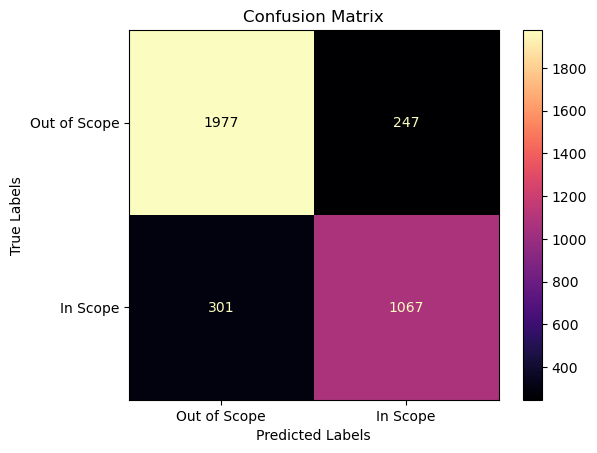

In [23]:
evaluate_file("./dev_pred.txt")

The model shows strong performance with an accuracy of 87% and balanced precision, recall, and F1-scores. The confusion matrix reveals that true negatives and false positives are well balanced, explaining the consistent metrics. The "Out of Scope" class performs better (f1-score: 0.90), likely due to its larger quantity (number of instances are 200%  that of "In Scope"), while the "In Scope" class still achieves decent results (f1-score: 0.79). Overall, the classifier is excellent for this dataset, but it was tested on consistent writing styles. Its performance may decline in more diverse contexts or with different text styles, which requires further testing and generalization.

## References

Abu-Jbara, A., & Radev, D. (2012). UMichigan: A conditional random field model for resolving the scope of negation. In SEM 2012: The First Joint Conference on Lexical and Computational Semantics – Volume 1: Proceedings of the main conference and the shared task, and Volume 2: Proceedings of the Sixth International Workshop on Semantic Evaluation (SemEval 2012) (pp. 328–334). Association for Computational Linguistics. https://www.aclweb.org/anthology/S12-1042

Councill, I., McDonald, R., & Velikovich, L. (2010). What's great and what's not: Learning to classify the scope of negation for improved sentiment analysis. Proceedings of the Workshop on Negation and Speculation in Natural Language Processing, 51–59.

Liang, X. (2020). How to Find Shortest Dependency Path with spaCy and StanfordNLP. Retrieved from https://towardsdatascience.com/how-to-find-shortest-dependency-path-with-spacy-and-stanfordnlp-539d45d28239

Reitan, J., Faret, J., Gambäck, B., & Bungum, L. (2015). Negation Scope Detection for Twitter Sentiment Analysis. Proceedings of the 6th Workshop on Computational Approaches to Subjectivity, Sentiment and Social Media Analysis, 99–108. Association for Computational Linguistics. https://doi.org/10.18653/v1/W15-2914

Shortest Paths. (n.d.). Retrieved from https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html

Sohn, S., Wu, S., & Chute, C. G. (2012). Dependency parser-based negation detection in clinical narratives. AMIA Joint Summits on Translational Science Proceedings, 2012, 1–8.

Zhong, Q., Li, P., Zhu, Q., Zhou, G., Luo, Z., & Luo, W. (2016). Speculation and negation scope detection via convolutional neural networks. Proceedings of the 2016 Conference on Empirical Methods in Natural Language Processing, 815–825. Austin, TX: Association for Computational Linguistics. https://doi.org/10.18653/v1/D16-1078